In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import figurefirst as fifi
import fly_plot_lib.plot as fpl
import os

import matplotlib as mpl

from splitflow import WindDataProcessing

In [2]:
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']
plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'

oranges = plt.cm.Oranges(np.linspace(0, 1, 10))
blues = plt.cm.Blues(np.linspace(0, 1, 10))
color_blue = oranges[6]
color_orange = blues[6]

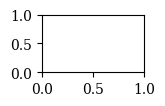

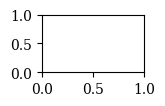

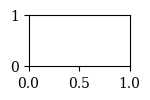

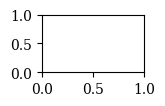

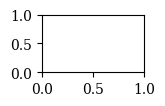

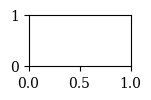

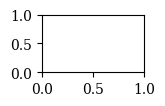

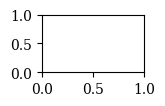

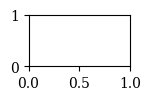

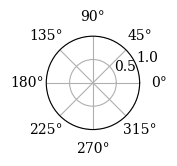

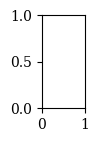

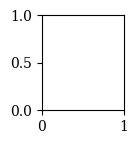

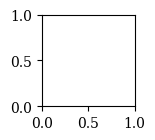

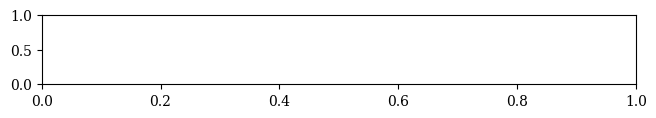

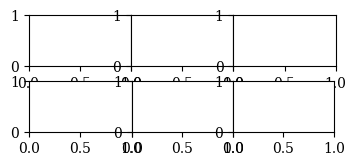

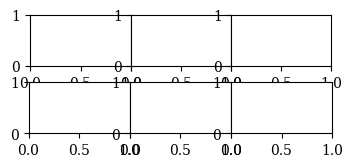

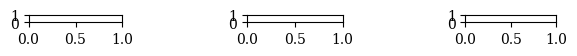

In [3]:
layout = fifi.svg_to_axes.FigureLayout('f2_template.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])



# Make colorbars separately 

In [4]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    '''
    https://stackoverflow.com/a/18926541
    '''
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap




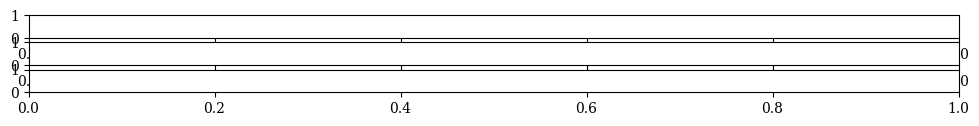

In [5]:
cmap_base = 'bwr'
vmin, vmax = 0.5, 1
Spectral_half_cmap = truncate_colormap(cmap_base, vmin, vmax)


fig, ax = plt.subplots(nrows=3, figsize=(12,1))
ax = layout.axes[('ColorBars', 'cb3')] 


sm = mpl.cm.ScalarMappable(cmap=cmap_base, norm=mpl.colors.Normalize(vmin=-50, vmax=50)) 
fig.colorbar(sm, cax=ax,  orientation='horizontal')
fifi.mpl_functions.adjust_spines(ax, ['bottom'], xticks=[-50,0,50], spine_locations={'bottom':5}, tick_length=3, linewidth=.5)

fifi.mpl_functions.set_fontsize(ax, 6)


layout.append_figure_to_layer(layout.figures['ColorBars'], 'ColorBars', cleartarget=True)



## Load in dfs

In [8]:
df_XZ = WindDataProcessing.load_wind_data('../../../Data/CFD/2D_PlanarSlices/XZslice','csv', coord_system='CFD')

xz__0.csv
xz__1.csv
xz__2.csv
xz__3.csv
xz__4.csv
xz__5.csv
xz__6.csv
xz__7.csv
xz__8.csv
xz__9.csv
xz__10.csv
xz__11.csv
xz__12.csv
xz__13.csv
xz__14.csv
xz__15.csv
xz__16.csv
xz__17.csv
xz__18.csv
xz__19.csv
xz__20.csv
xz__21.csv
xz__22.csv
xz__23.csv
xz__24.csv
xz__25.csv
xz__26.csv
xz__27.csv
xz__28.csv
xz__29.csv
xz__30.csv
xz__31.csv
xz__32.csv
xz__33.csv
xz__34.csv
xz__35.csv
xz__36.csv
xz__37.csv
xz__38.csv
xz__39.csv
xz__40.csv
xz__41.csv
xz__42.csv
xz__43.csv
xz__44.csv
xz__45.csv
xz__46.csv
xz__47.csv
xz__48.csv
xz__49.csv
xz__50.csv
xz__51.csv
xz__52.csv
xz__53.csv
xz__54.csv
xz__55.csv
xz__56.csv
xz__57.csv
xz__58.csv
xz__59.csv
xz__60.csv
xz__61.csv
xz__62.csv
xz__63.csv
xz__64.csv
xz__65.csv
xz__66.csv
xz__67.csv
xz__68.csv
xz__69.csv
xz__70.csv
xz__71.csv
xz__72.csv
xz__73.csv
xz__74.csv
xz__75.csv
xz__76.csv
xz__77.csv
xz__78.csv
xz__79.csv
xz__80.csv
xz__81.csv
xz__82.csv
xz__83.csv
xz__84.csv
xz__85.csv
xz__86.csv
xz__87.csv
xz__88.csv
xz__89.csv
xz__90.csv
xz__91.cs

In [9]:
def chunks(lst, n):
    arrays = []
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        arrays.append(lst[i:i + n])
    return arrays    

# XZ plane

## Instantaneous vorticity

In [37]:
newdf1 = df_XZ[df_XZ['Time']==25]

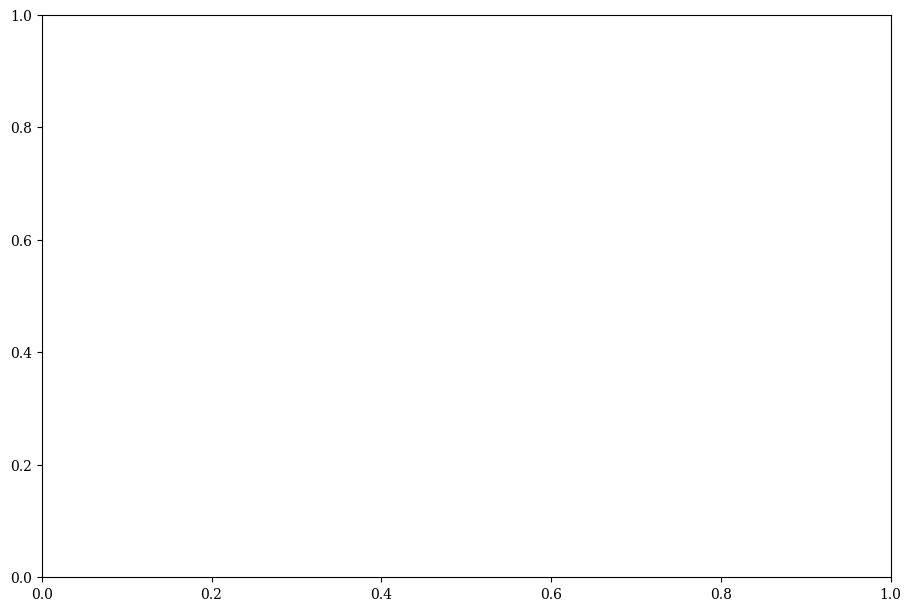

In [38]:
# Prepare the grid
grid_x, grid_y = np.meshgrid(
    np.unique(newdf1['x']),
    np.unique(newdf1['z']),
)

# Interpolate to fill missing values
grid_z = griddata(
    (newdf1['x'], newdf1['z']),  # Original data points
    newdf1['vorticity_z'],         # Values at those points
    (grid_x, grid_y),   # Grid to interpolate onto
    method='linear'     # Interpolation method
)

fig, ax = plt.subplots(figsize=(9, 6),layout='constrained')
ax = layout.axes[('M', 'm')]
mesh=ax.pcolormesh(grid_x, grid_y, grid_z, vmin=-50,vmax=50, shading='auto', cmap=cmap_base)

#fig.colorbar(mesh, location='top',aspect=40).outline.set_visible(False)

ax.quiver(nearest_points['x'], nearest_points['z'], nearest_points['xvel'], nearest_points['zvel'], angles='xy', scale_units='xy', scale=10, color='grey')

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('#dc2b94ff') #((87,192,225,100) ) #f747a5ff
    spine.set_linewidth(1)  


ax.set_aspect('equal')

ax.set_rasterized(True)

fifi.mpl_functions.set_fontsize(ax, 6)

layout.append_figure_to_layer(layout.figures['M'], 'M', cleartarget=True)